In [15]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from collections import Counter
from wordcloud import WordCloud

In [16]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
data = {
    "Article": [

        "India won the cricket world cup after defeating Australia.",

        "The government introduced a new education policy.",

        "Apple launched a new AI powered smartphone.",

        "The stock market reached a record high today.",

        "The latest movie received excellent audience reviews.",

        "Scientists developed a new space exploration technology.",

        "The football team won the national championship.",

        "The parliament passed a new economic bill.",

        "A famous actor won the best performance award.",

        "New software makes online banking more secure."

    ],

    "Category": [

        "Sports",

        "Politics",

        "Technology",

        "Business",

        "Entertainment",

        "Technology",

        "Sports",

        "Politics",

        "Entertainment",

        "Business"

    ]
}

df = pd.DataFrame(data)

print("News Dataset")

print(df)

News Dataset
                                             Article       Category
0  India won the cricket world cup after defeatin...         Sports
1  The government introduced a new education policy.       Politics
2        Apple launched a new AI powered smartphone.     Technology
3      The stock market reached a record high today.       Business
4  The latest movie received excellent audience r...  Entertainment
5  Scientists developed a new space exploration t...     Technology
6   The football team won the national championship.         Sports
7         The parliament passed a new economic bill.       Politics
8     A famous actor won the best performance award.  Entertainment
9     New software makes online banking more secure.       Business


In [18]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Article"] = df["Article"].apply(clean_text)

print(df[["Article","Cleaned_Article"]])

                                             Article  \
0  India won the cricket world cup after defeatin...   
1  The government introduced a new education policy.   
2        Apple launched a new AI powered smartphone.   
3      The stock market reached a record high today.   
4  The latest movie received excellent audience r...   
5  Scientists developed a new space exploration t...   
6   The football team won the national championship.   
7         The parliament passed a new economic bill.   
8     A famous actor won the best performance award.   
9     New software makes online banking more secure.   

                                     Cleaned_Article  
0        india cricket world cup defeating australia  
1         government introduced new education policy  
2           apple launched new ai powered smartphone  
3             stock market reached record high today  
4   latest movie received excellent audience reviews  
5  scientists developed new space exploration tec... 

In [19]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Article"])

y = df["Category"]

In [20]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [21]:
model = MultinomialNB()

model.fit(X_train,y_train)

MultinomialNB()

In [22]:
y_pred = model.predict(X_test)

print("Predicted Categories")

print(y_pred)

Predicted Categories
['Sports' 'Technology']


In [23]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.0


In [25]:
print(classification_report(y_test,y_pred))

               precision    recall  f1-score   support

Entertainment       0.00      0.00      0.00       1.0
     Politics       0.00      0.00      0.00       1.0
       Sports       0.00      0.00      0.00       0.0
   Technology       0.00      0.00      0.00       0.0

     accuracy                           0.00       2.0
    macro avg       0.00      0.00      0.00       2.0
 weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [26]:
cm = confusion_matrix(y_test,y_pred)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[0 0 1 0]
 [0 0 0 1]
 [0 0 0 0]
 [0 0 0 0]]


In [27]:
news = [

    "Microsoft launched a new artificial intelligence software.",

    "India defeated England in the cricket match.",

    "The Prime Minister announced a new tax policy.",

    "The company reported huge profits this quarter.",

    "The actress won the national film award."

]

clean_news = []

for article in news:

    clean_news.append(clean_text(article))

news_vector = vectorizer.transform(clean_news)

prediction = model.predict(news_vector)

for article,category in zip(news,prediction):

    print(article)

    print("Category :",category)

    print()

Microsoft launched a new artificial intelligence software.
Category : Technology

India defeated England in the cricket match.
Category : Sports

The Prime Minister announced a new tax policy.
Category : Technology

The company reported huge profits this quarter.
Category : Business

The actress won the national film award.
Category : Sports



In [28]:
all_words = " ".join(df["Cleaned_Article"])

word_list = all_words.split()

word_freq = Counter(word_list)

print("Top 10 Common Words")

print(word_freq.most_common(10))

Top 10 Common Words
[('new', 5), ('india', 1), ('cricket', 1), ('world', 1), ('cup', 1), ('defeating', 1), ('australia', 1), ('government', 1), ('introduced', 1), ('education', 1)]


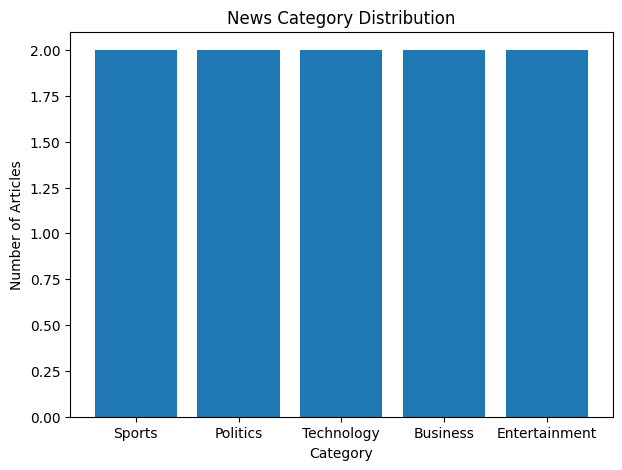

In [29]:
category_count = df["Category"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(category_count.index,category_count.values)

plt.title("News Category Distribution")

plt.xlabel("Category")

plt.ylabel("Number of Articles")

plt.show()

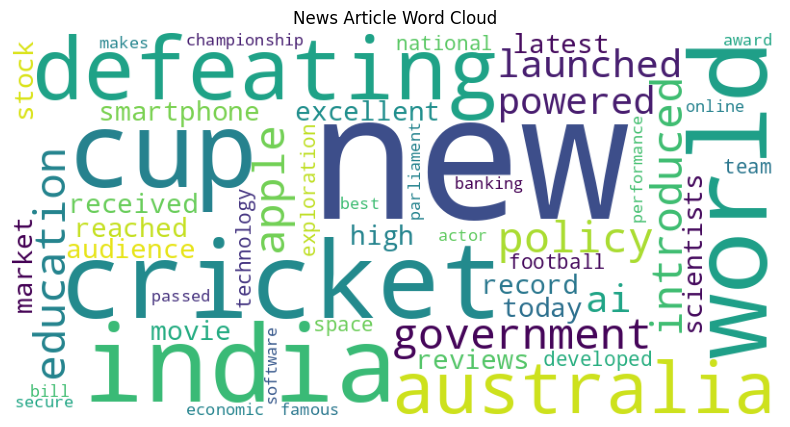

In [30]:
wordcloud = WordCloud(

    width=800,

    height=400,

    background_color="white"

).generate(all_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("News Article Word Cloud")

plt.show()

In [31]:
sports = len(df[df["Category"]=="Sports"])
politics = len(df[df["Category"]=="Politics"])
technology = len(df[df["Category"]=="Technology"])
business = len(df[df["Category"]=="Business"])
entertainment = len(df[df["Category"]=="Entertainment"])

print("News Article Classification Report")

print("-----------------------------------")

print("Sports Articles :",sports)

print("Politics Articles :",politics)

print("Technology Articles :",technology)

print("Business Articles :",business)

print("Entertainment Articles :",entertainment)

print("\nModel Accuracy")

print(accuracy)

print("\nTop Keywords")

print(word_freq.most_common(10))

print("\nRecommendation")

print("The NLP model successfully classifies news articles into Sports, Politics, Technology, Business, and Entertainment categories. This system helps organize news automatically and improves content management.")

News Article Classification Report
-----------------------------------
Sports Articles : 2
Politics Articles : 2
Technology Articles : 2
Business Articles : 2
Entertainment Articles : 2

Model Accuracy
0.0

Top Keywords
[('new', 5), ('india', 1), ('cricket', 1), ('world', 1), ('cup', 1), ('defeating', 1), ('australia', 1), ('government', 1), ('introduced', 1), ('education', 1)]

Recommendation
The NLP model successfully classifies news articles into Sports, Politics, Technology, Business, and Entertainment categories. This system helps organize news automatically and improves content management.
